# 决策树规则提取器

本 notebook 演示两类决策树规则提取工具的使用流程：

| 工具 | 说明 |
|------|------|
| **DecisionTreeAnalyzer** | 标准 sklearn 决策树训练与评估（AUC/KS/LIFT 指标、save/load、规则提取） |
| **ManualTreeExtractor** | 人工干预决策树节点分裂（业务经验注入模型） |

**使用场景**：
- DecisionTreeAnalyzer：快速建立基线决策树，评估模型效果，提取可运营规则
- ManualTreeExtractor：数据驱动分裂不符合业务经验时，用人工阈值替换自动分裂

In [1]:
import os, sys
sys.path.append('../')

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hscredit.report.mining import DecisionTreeAnalyzer, ManualTreeExtractor
from hscredit.utils import style_rule_table
from hscredit import init_setting

init_setting()

## 1. 加载数据

In [3]:
# 加载示例数据
df = pd.read_excel('hscredit_yyp.xlsx')

target = 'FPD'
print(f'样本数: {len(df):,}')
print(f'坏账率: {df[target].mean():.2%}')

# 选取用于建模的数值特征（排除ID、时间、标签列）
exclude_cols = ['客户编号', '放款时间', '商品类别', 'MOB1', 'CURRENT_DPD', target]
feature_list = [c for c in df.columns if c not in exclude_cols 
                and pd.api.types.is_numeric_dtype(df[c])]
print(f'建模特征 ({len(feature_list)} 个)')

# 划分训练集和测试集
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.3, random_state=42, stratify=df[target])
print(f'训练集: {len(df_train):,} 条, 坏账率: {df_train[target].mean():.2%}')
print(f'测试集: {len(df_test):,} 条, 坏账率: {df_test[target].mean():.2%}')

样本数: 970
坏账率: 14.02%
建模特征 (12 个)
训练集: 679 条, 坏账率: 13.99%
测试集: 291 条, 坏账率: 14.09%


---

# Part A — DecisionTreeAnalyzer

**标准 sklearn 决策树包装器**，支持 AUC/KS/LIFT 等模型评估指标计算、规则提取与模型持久化。

## A1. 训练决策树

In [4]:
# 初始化并训练决策树
fitter = DecisionTreeAnalyzer(
    target=target,
    features=feature_list,
)
fitter.fit(df_train)

print(fitter)
print(f'叶子节点 ID: {fitter.get_leaf_node_ids()}')

DecisionTreeAnalyzer(target='FPD', features=['放款金额', '中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3', '轻花老客海纳子分V1', '天创小额网贷分', '近六个月非银多头机构数', '手机号近一个月非银多头机构数', '身份证近一个月非银多头机构数', '衡枢鉴真分老客版'], leaves=4)
叶子节点 ID: [2, 3, 5, 6]


## A2. 决策树可视化

训练完成后，使用 `hscredit.core.viz.plot_tree` 绘制决策树结构图，使用 `feature_importance_plot` 绘制特征重要性图：

## A3. 模型评估

`evaluate()` 支持 **AUC / KS / LIFT / TOP** 四种指标，同时计算训练集和多个测试集。


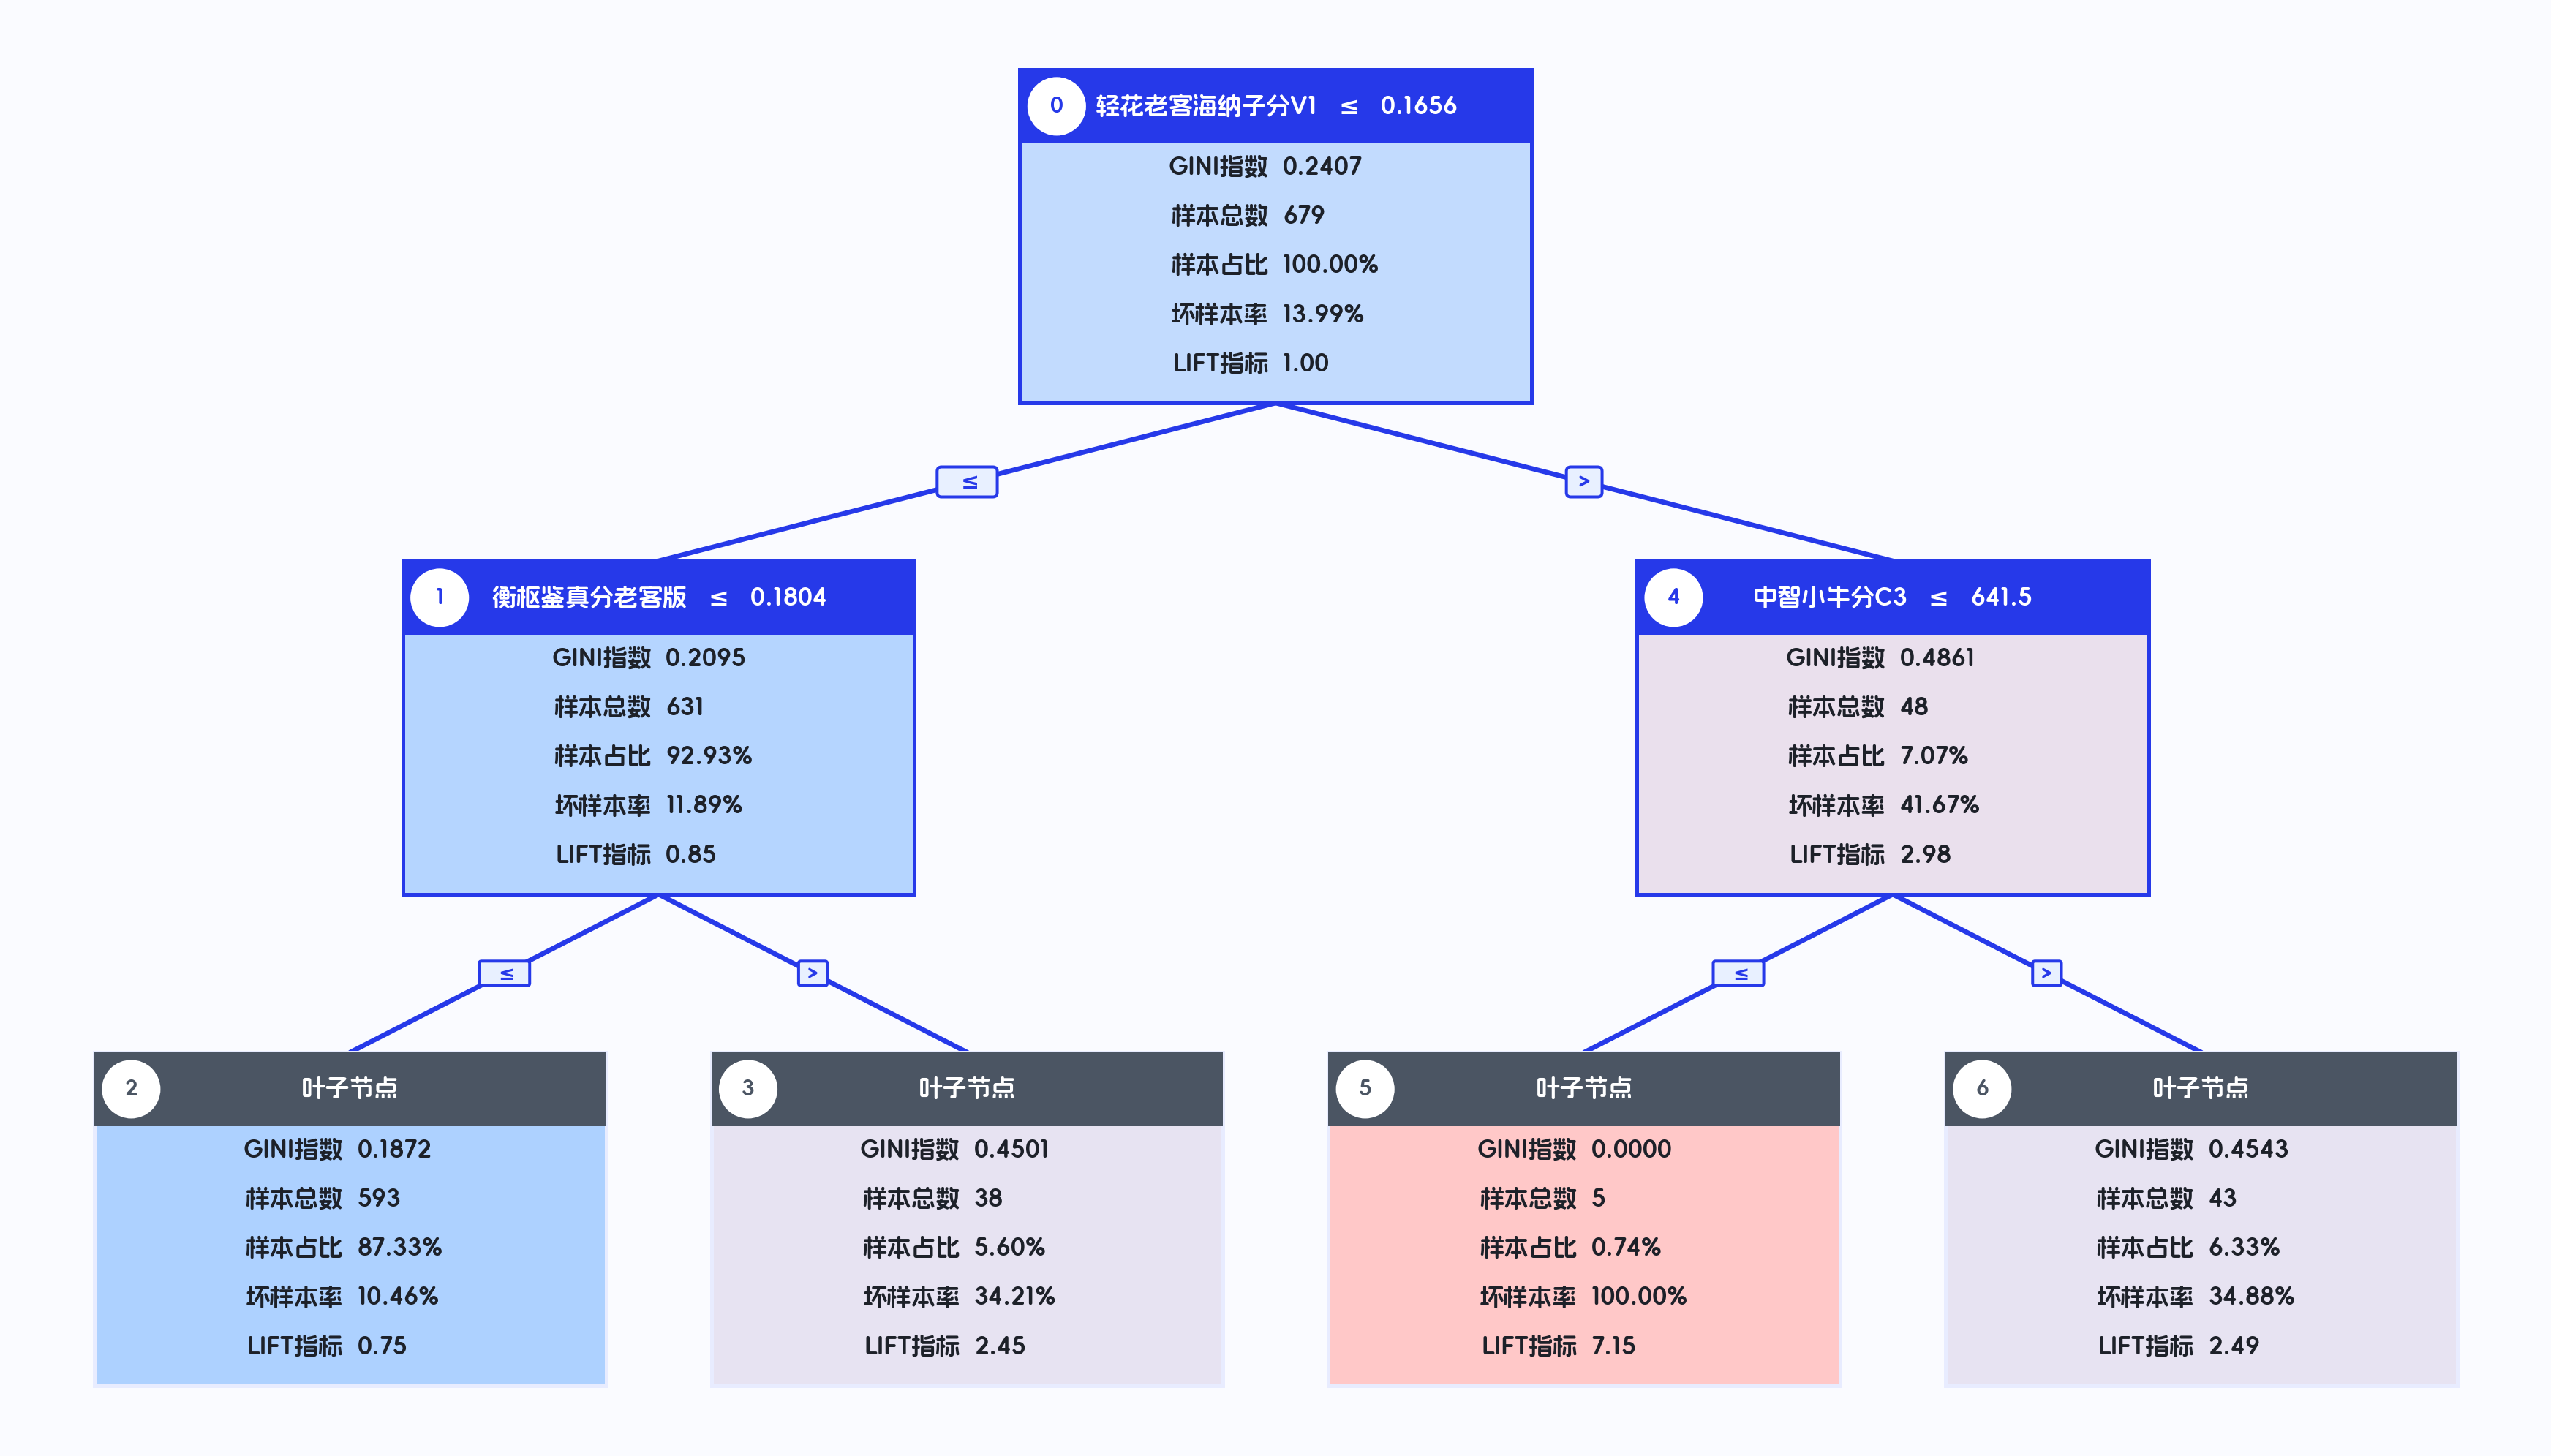

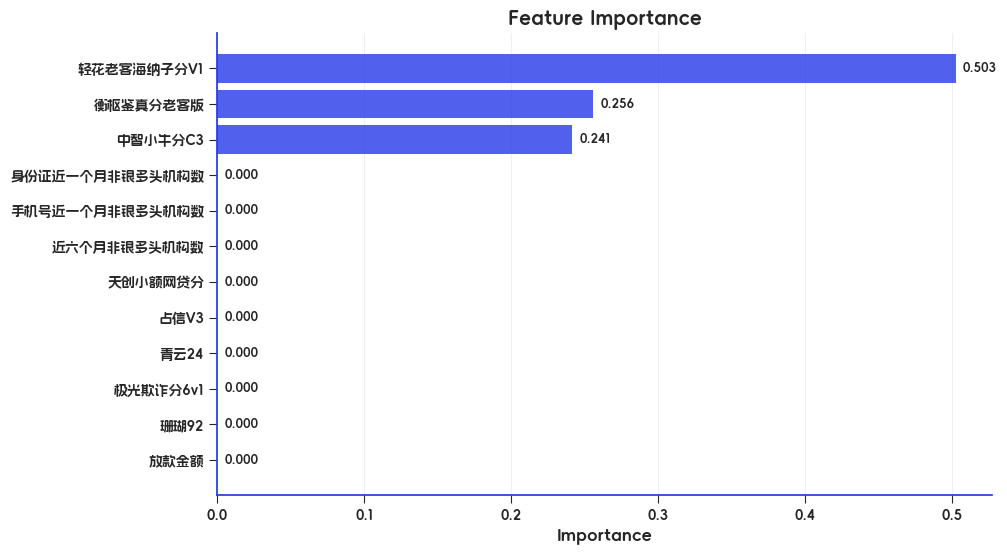

In [5]:
from hscredit.core.viz import plot_tree, feature_importance_plot

# 绘制决策树结构图（matplotlib 后端）
output_dir = './model_report'
os.makedirs(output_dir, exist_ok=True)

fig_tree = plot_tree(
    fitter.clf,
    backend='matplotlib',
    feature_names=feature_list,
    class_names=['好', '坏'],
    save=f'{output_dir}/tree_analyzer_structure.png',
)
plt.show()

# 绘制特征重要性图
fig_imp = feature_importance_plot(
    features=feature_list,
    importance=fitter.clf.feature_importances_,
    top_n=12,
    figsize=(10, 6),
    save=f'{output_dir}/tree_analyzer_importance.png',
)
plt.show()

In [6]:
# 多指标评估
for metric_type in ['auc', 'ks', 'lift', 'top']:
    result = fitter.evaluate(
        test_data_list=[('测试集', df_test)],
        metric_type=metric_type,
        top_rate=0.1  # lift/top 指标取 top 10%
    )
    for name, value in result:
        print(f'  {metric_type.upper():6s} | {name}: {value:.4f}')

  AUC    | 训练集: 0.6308
  AUC    | 测试集: 0.5493
  KS     | 训练集: 0.2921
  KS     | 测试集: 0.1902
  LIFT   | 训练集: 2.9870
  LIFT   | 测试集: 1.9579
  TOP    | 训练集: 2.9870
  TOP    | 测试集: 1.9579


## A4. 规则效果表

`get_rule_table()` 返回树中每个节点的统计指标：


In [7]:
# get_rule_table() 现在与 report() 同口径：
# 从每个节点提取规则，在数据集（默认训练集）上用 rule.report 计算命中效果
rule_table = fitter.get_rule_table()
style_rule_table(rule_table, overall_badrate=df_train[target].mean())

,节点编号,是否叶子,指标含义,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,1,否,轻花老客海纳子分V1 <= 0.1656(含缺失),631,92.93%,556,95.21%,75,78.95%,11.89%,0.85,-197.81%,-212.85%,15.17%,11.89%,78.95%,20.66%
1,2,是,衡枢鉴真分老客版 <= 0.1804(含缺失) 且 轻花老客海纳子分V1 <= 0.1656(含缺失),593,87.33%,531,90.92%,62,65.26%,10.46%,0.75,-174.26%,-199.53%,16.94%,10.46%,65.26%,18.02%
2,3,是,衡枢鉴真分老客版 > 0.1804 且 轻花老客海纳子分V1 <= 0.1656(含缺失),38,5.60%,25,4.28%,13,13.68%,34.21%,2.45,8.57%,153.08%,84.24%,34.21%,13.68%,19.55%
3,4,否,轻花老客海纳子分V1 > 0.1656,48,7.07%,28,4.79%,20,21.05%,41.67%,2.98,15.05%,212.85%,84.83%,41.67%,21.05%,27.97%
4,5,是,中智小牛分C3 <= 641.5000 且 轻花老客海纳子分V1 > 0.1656,5,0.74%,0,0.00%,5,5.26%,100.00%,7.15,4.56%,619.30%,86.75%,100.00%,5.26%,10.00%
5,6,是,中智小牛分C3 > 641.5000(含缺失) 且 轻花老客海纳子分V1 > 0.1656,43,6.33%,28,4.79%,15,15.79%,34.88%,2.49,10.10%,159.42%,84.09%,34.88%,15.79%,21.74%


## A5. 按节点评估数据

`report()` 在新数据集上评估指定节点的命中效果：


In [8]:
node_eval = fitter.report(df_test)
style_rule_table(node_eval, overall_badrate=df_test[target].mean())

,节点编号,是否叶子,指标含义,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,1,否,轻花老客海纳子分V1 <= 0.1656(含缺失),274,94.16%,236,94.40%,38,92.68%,13.87%,0.98,-25.25%,-26.82%,17.87%,13.87%,92.68%,24.13%
1,2,是,衡枢鉴真分老客版 <= 0.1804(含缺失) 且 轻花老客海纳子分V1 <= 0.1656(含缺失),260,89.35%,227,90.80%,33,80.49%,12.69%,0.90,-83.16%,-93.08%,19.24%,12.69%,80.49%,21.93%
2,3,是,衡枢鉴真分老客版 > 0.1804 且 轻花老客海纳子分V1 <= 0.1656(含缺失),14,4.81%,9,3.60%,5,12.20%,35.71%,2.53,7.76%,161.24%,84.54%,35.71%,12.20%,18.18%
3,4,否,轻花老客海纳子分V1 > 0.1656,17,5.84%,14,5.60%,3,7.32%,17.65%,1.25,1.57%,26.82%,82.13%,17.65%,7.32%,10.34%
4,5,是,中智小牛分C3 <= 641.5000 且 轻花老客海纳子分V1 > 0.1656,1,0.34%,1,0.40%,0,0.00%,0.00%,0.00,-0.34%,-100.34%,85.57%,0.00%,0.00%,0.00%
5,6,是,中智小牛分C3 > 641.5000(含缺失) 且 轻花老客海纳子分V1 > 0.1656,16,5.50%,13,5.20%,3,7.32%,18.75%,1.33,1.92%,35.00%,82.47%,18.75%,7.32%,10.53%


## A6. 导出 Rule 对象并生成报告

`get_rules()` 将叶子节点规则转换为 `Rule` 对象，可进一步调用 `Rule.report()` 生成详细报告：


In [9]:
rules = fitter.get_rules()
print(f'叶子规则共 {len(rules)} 条:\n')
for r in rules:
    print(f'[{r.name}]')
    print(f'  表达式: {r.expr}')
    print(f'  描述: {r.description}')
    print()

叶子规则共 4 条:

[DecisionTree_N2]
  表达式: ((衡枢鉴真分老客版 <= 0.18043826520442963) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & ((轻花老客海纳子分V1 <= 0.16560570895671844) | (轻花老客海纳子分V1 != 轻花老客海纳子分V1))
  描述: 衡枢鉴真分老客版 <= 0.1804(含缺失) 且 轻花老客海纳子分V1 <= 0.1656(含缺失)

[DecisionTree_N3]
  表达式: (衡枢鉴真分老客版 > 0.18043826520442963) & ((轻花老客海纳子分V1 <= 0.16560570895671844) | (轻花老客海纳子分V1 != 轻花老客海纳子分V1))
  描述: 衡枢鉴真分老客版 > 0.1804 且 轻花老客海纳子分V1 <= 0.1656(含缺失)

[DecisionTree_N5]
  表达式: (中智小牛分C3 <= 641.5) & (轻花老客海纳子分V1 > 0.16560570895671844)
  描述: 中智小牛分C3 <= 641.5000 且 轻花老客海纳子分V1 > 0.1656

[DecisionTree_N6]
  表达式: ((中智小牛分C3 > 641.5) | (中智小牛分C3 != 中智小牛分C3)) & (轻花老客海纳子分V1 > 0.16560570895671844)
  描述: 中智小牛分C3 > 641.5000(含缺失) 且 轻花老客海纳子分V1 > 0.1656



In [10]:
# 找 LIFT 最高的叶子规则
leaf_rules = rule_table[rule_table['是否叶子'] == '是'].sort_values('LIFT值', ascending=False)
best = leaf_rules.iloc[0]
print(f'最高LIFT叶子: 节点 {int(best["节点编号"])}')
print(f'规则: {best["指标含义"]}')
print(f'样本占比: {best["样本占比"]:.2%}, 坏样本率: {best["坏样本率"]:.2%}, LIFT: {best["LIFT值"]:.4f}')

# 找到对应 Rule 对象，生成详细报告
best_rule = next((r for r in rules if r.name == f'DecisionTree_N{int(best["节点编号"])}'), None)
if best_rule:
    report = best_rule.report(df_test, target=target)
    print('\n【Rule.report 详细报告】')
    display(report)

最高LIFT叶子: 节点 5
规则: 中智小牛分C3 <= 641.5000 且 轻花老客海纳子分V1 > 0.1656
样本占比: 0.74%, 坏样本率: 100.00%, LIFT: 7.1474

【Rule.report 详细报告】


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,(中智小牛分C3 <= 641.5) & (轻花老客海纳子分V1 > 0.16560570895671844),命中,1,0.0034,1,0.0040,0,0.0000,0.0000,0.0000,-0.0034,-1.0034,0.8557,0.0000,0.0000,0.0000
1,验证规则,(中智小牛分C3 <= 641.5) & (轻花老客海纳子分V1 > 0.16560570895671844),未命中,290,0.9966,249,0.9960,41,1.0000,0.1414,1.0034,1.0000,1.0034,0.1443,0.1414,1.0000,0.2477


## A7. 模型持久化

`save()` / `load()` 支持模型的保存和加载：


In [11]:
fitter.save('/tmp/dt_model.pkl')
fitter_loaded = DecisionTreeAnalyzer.load('/tmp/dt_model.pkl')
print(f'加载后: {fitter_loaded}')
loaded_metrics = fitter_loaded.evaluate([('测试集', df_test)], metric_type='ks')
print(f'加载后 KS: {[(n, round(v,4)) for n,v in loaded_metrics]}')

加载后: DecisionTreeAnalyzer(target='FPD', features=['放款金额', '中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3', '轻花老客海纳子分V1', '天创小额网贷分', '近六个月非银多头机构数', '手机号近一个月非银多头机构数', '身份证近一个月非银多头机构数', '衡枢鉴真分老客版'], leaves=4)
加载后 KS: [('训练集', 0.2921), ('测试集', 0.1902)]


---

# Part B — ManualTreeExtractor

**人工决策树提取器**，支持对 sklearn 决策树进行**人工指定分裂阈值**，
从而将业务经验注入数据驱动的模型。

## B1. 训练基础决策树 + 规则验证

训练基础决策树，绘制决策树结构图、特征重要性图，并在 df_train 上通过 `rule.report()` 独立验证每条规则的有效性。

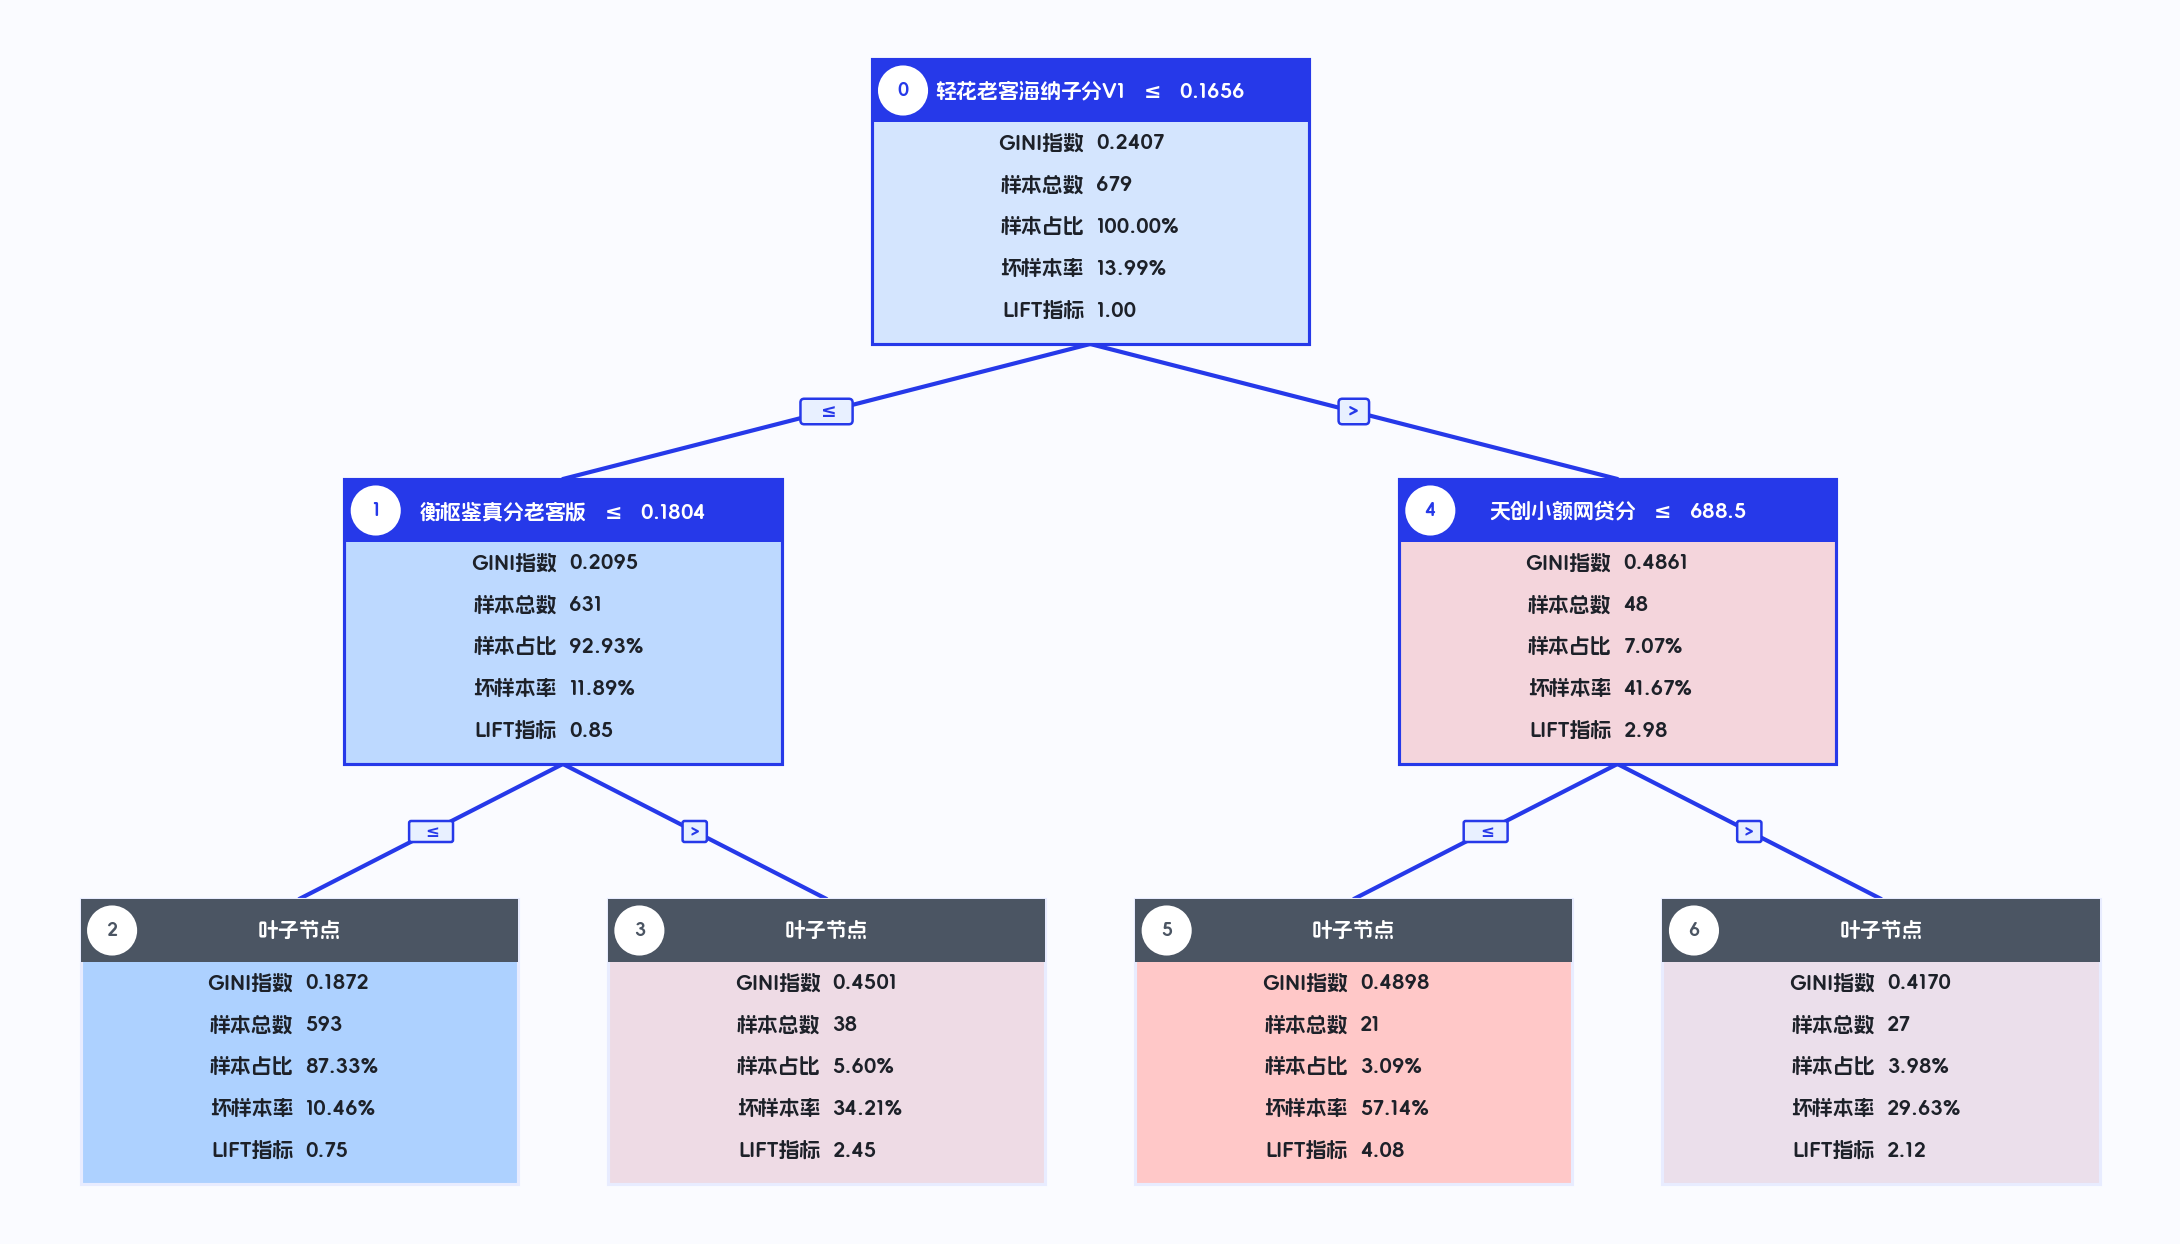

,节点编号,是否叶子,指标含义,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,1,否,轻花老客海纳子分V1 <= 0.1656(含缺失),631,92.93%,556,95.21%,75,78.95%,11.89%,0.85,-197.81%,-212.85%,15.17%,11.89%,78.95%,20.66%
1,2,是,衡枢鉴真分老客版 <= 0.1804(含缺失) 且 轻花老客海纳子分V1 <= 0.1656(含缺失),593,87.33%,531,90.92%,62,65.26%,10.46%,0.75,-174.26%,-199.53%,16.94%,10.46%,65.26%,18.02%
2,3,是,衡枢鉴真分老客版 > 0.1804 且 轻花老客海纳子分V1 <= 0.1656(含缺失),38,5.60%,25,4.28%,13,13.68%,34.21%,2.45,8.57%,153.08%,84.24%,34.21%,13.68%,19.55%
3,4,否,轻花老客海纳子分V1 > 0.1656,48,7.07%,28,4.79%,20,21.05%,41.67%,2.98,15.05%,212.85%,84.83%,41.67%,21.05%,27.97%
4,5,是,天创小额网贷分 <= 688.5000 且 轻花老客海纳子分V1 > 0.1656,21,3.09%,9,1.54%,12,12.63%,57.14%,4.08,9.84%,318.26%,86.45%,57.14%,12.63%,20.69%
5,6,是,天创小额网贷分 > 688.5000(含缺失) 且 轻花老客海纳子分V1 > 0.1656,27,3.98%,19,3.25%,8,8.42%,29.63%,2.12,4.63%,116.40%,84.39%,29.63%,8.42%,13.11%


ManualTreeExtractor(target='FPD', features=['放款金额', '中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3', '轻花老客海纳子分V1', '天创小额网贷分', '近六个月非银多头机构数', '手机号近一个月非银多头机构数', '身份证近一个月非银多头机构数', '衡枢鉴真分老客版'], samples=679, leaves=4)
总体样本数: 679
总体坏账率: 13.99%


In [12]:
# 初始化并训练基础树
ext = ManualTreeExtractor(
    target=target,
    max_depth=2,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
ext.fit(df_train, features=feature_list)

# display() 一行展示：决策树 graphviz 图 + 美化规则表
ext.display()

print(ext)
print(f'总体样本数: {ext._n_total_samples:,}')
print(f'总体坏账率: {ext._overall_badrate:.2%}')

In [13]:
# 不依赖树结构，在 df_train 上用 rule.report() 验证每条规则
print('【rule.report() 验证 — 在 df_train 上独立评估每条规则】\n')
rules_ext = ext.get_rules()
for rule in rules_ext:
    print(f"[{rule.name}] {rule.description}")
    display(rule.report(df_train, target=target))
    print()

【rule.report() 验证 — 在 df_train 上独立评估每条规则】

[TreeNode_2] 衡枢鉴真分老客版 <= 0.1804(含缺失) 且 轻花老客海纳子分V1 <= 0.1656(含缺失)


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,((衡枢鉴真分老客版 <= 0.18043826520442963) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & ((轻花老客海纳子分V1 <= 0.16560570895671844) | (轻花老客海纳子分V1 != 轻花老客海纳子分V1)),命中,593,0.8733,531,0.9092,62,0.6526,0.1046,0.7473,-1.7426,-1.9953,0.1694,0.1046,0.6526,0.1802
1,验证规则,((衡枢鉴真分老客版 <= 0.18043826520442963) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & ((轻花老客海纳子分V1 <= 0.16560570895671844) | (轻花老客海纳子分V1 != 轻花老客海纳子分V1)),未命中,86,0.1267,53,0.0908,33,0.3474,0.3837,2.7426,0.2527,1.9953,0.8306,0.3837,0.3474,0.3646



[TreeNode_3] 衡枢鉴真分老客版 > 0.1804 且 轻花老客海纳子分V1 <= 0.1656(含缺失)


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,(衡枢鉴真分老客版 > 0.18043826520442963) & ((轻花老客海纳子分V1 <= 0.16560570895671844) | (轻花老客海纳子分V1 != 轻花老客海纳子分V1)),命中,38,0.0560,25,0.0428,13,0.1368,0.3421,2.4452,0.0857,1.5308,0.8424,0.3421,0.1368,0.1955
1,验证规则,(衡枢鉴真分老客版 > 0.18043826520442963) & ((轻花老客海纳子分V1 <= 0.16560570895671844) | (轻花老客海纳子分V1 != 轻花老客海纳子分V1)),未命中,641,0.9440,559,0.9572,82,0.8632,0.1279,0.9143,-1.4452,-1.5308,0.1576,0.1279,0.8632,0.2228



[TreeNode_5] 天创小额网贷分 <= 688.5000 且 轻花老客海纳子分V1 > 0.1656


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,(天创小额网贷分 <= 688.5) & (轻花老客海纳子分V1 > 0.16560570895671844),命中,21,0.0309,9,0.0154,12,0.1263,0.5714,4.0842,0.0984,3.1826,0.8645,0.5714,0.1263,0.2069
1,验证规则,(天创小额网贷分 <= 688.5) & (轻花老客海纳子分V1 > 0.16560570895671844),未命中,658,0.9691,575,0.9846,83,0.8737,0.1261,0.9016,-3.0842,-3.1826,0.1355,0.1261,0.8737,0.2205



[TreeNode_6] 天创小额网贷分 > 688.5000(含缺失) 且 轻花老客海纳子分V1 > 0.1656


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,((天创小额网贷分 > 688.5) | (天创小额网贷分 != 天创小额网贷分)) & (轻花老客海纳子分V1 > 0.16560570895671844),命中,27,0.0398,19,0.0325,8,0.0842,0.2963,2.1177,0.0463,1.1640,0.8439,0.2963,0.0842,0.1311
1,验证规则,((天创小额网贷分 > 688.5) | (天创小额网贷分 != 天创小额网贷分)) & (轻花老客海纳子分V1 > 0.16560570895671844),未命中,652,0.9602,565,0.9675,87,0.9158,0.1334,0.9537,-1.1177,-1.1640,0.1561,0.1334,0.9158,0.2329


## B2. 人工指定阈值分裂 + 规则验证

用业务经验阈值替换根分裂，并在 df_train 上通过 `rule.report()` 验证分裂后每条规则的有效性。

- `threshold=float` → 以指定阈值分裂
- `threshold=None` → 用决策树自动计算最优阈值
- `node` → 分裂的目标节点 ID（默认 0=根节点）

【人工指定阈值分裂】特征=身份证近一个月非银多头机构数, 阈值=15, 节点=0（根节点）


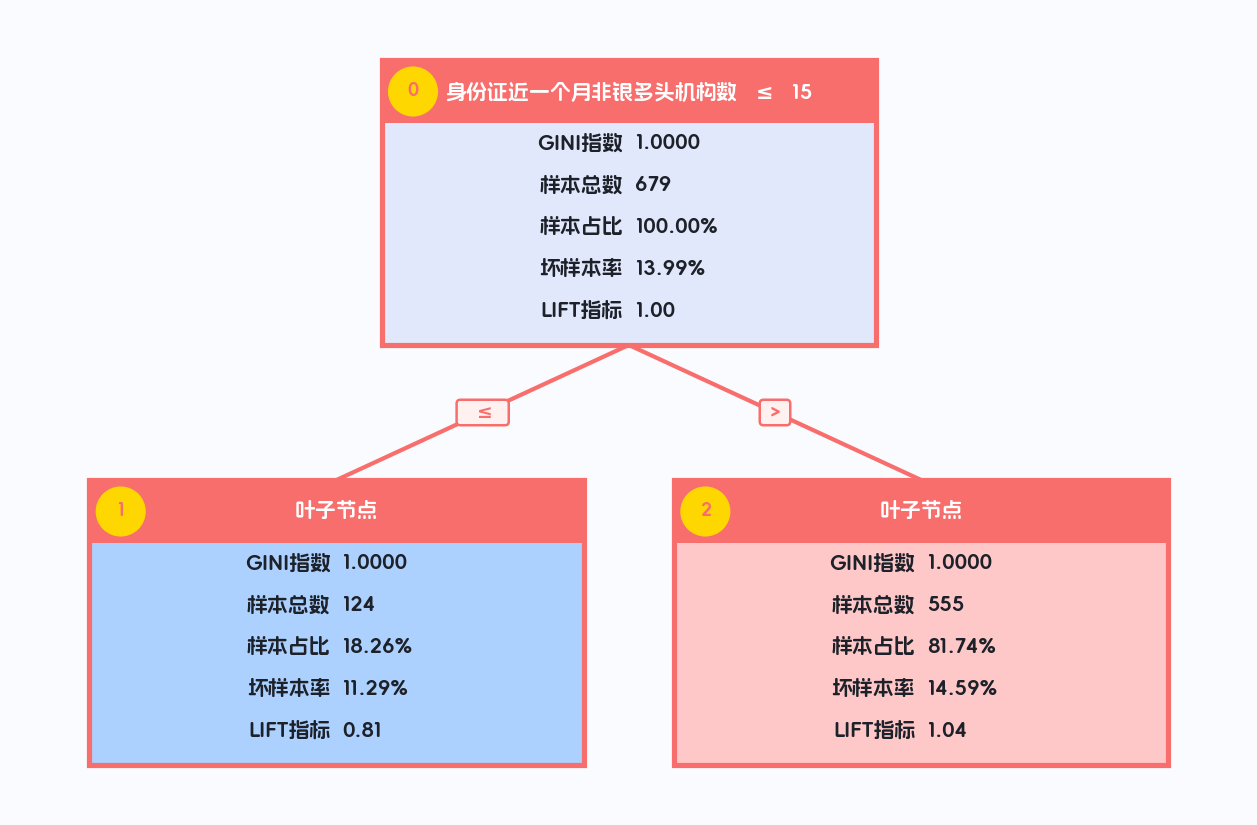

,节点编号,是否叶子,指标含义,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,1,是,身份证近一个月非银多头机构数 <= 15.0000,124,18.26%,110,18.84%,14,14.74%,11.29%,0.81,-4.31%,-23.62%,71.87%,11.29%,14.74%,12.79%
1,2,是,身份证近一个月非银多头机构数 > 15.0000(含缺失),555,81.74%,474,81.16%,81,85.26%,14.59%,1.04,19.30%,23.62%,28.13%,14.59%,85.26%,24.92%


ManualTreeExtractor(target='FPD', features=['放款金额', '中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3', '轻花老客海纳子分V1', '天创小额网贷分', '近六个月非银多头机构数', '手机号近一个月非银多头机构数', '身份证近一个月非银多头机构数', '衡枢鉴真分老客版'], samples=679, leaves=2)

In [14]:
# 人工指定阈值分裂
FEATURE = '身份证近一个月非银多头机构数'
THRESHOLD = 15

print(f'【人工指定阈值分裂】特征={FEATURE}, 阈值={THRESHOLD}, 节点=0（根节点）')
ext.manual_split(
    data=df_train,
    feature=FEATURE,
    threshold=THRESHOLD,
    node=0
)

# display() 一行展示：决策树 graphviz 图 + 美化规则表
ext.display()

In [15]:
# 不依赖树结构，在 df_train 上用 rule.report() 验证每条规则
print('【rule.report() 验证 — 在 df_train 上独立评估每条规则】\n')
for rule in ext.get_rules():
    print(f"[{rule.name}] {rule.description}")
    display(rule.report(df_train, target=target))
    print()

【rule.report() 验证 — 在 df_train 上独立评估每条规则】

[TreeNode_1] 身份证近一个月非银多头机构数 <= 15.0000


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,(身份证近一个月非银多头机构数 <= 15.0),命中,124,0.1826,110,0.1884,14,0.1474,0.1129,0.8070,-0.0431,-0.2362,0.7187,0.1129,0.1474,0.1279
1,验证规则,(身份证近一个月非银多头机构数 <= 15.0),未命中,555,0.8174,474,0.8116,81,0.8526,0.1459,1.0431,0.1930,0.2362,0.2813,0.1459,0.8526,0.2492



[TreeNode_2] 身份证近一个月非银多头机构数 > 15.0000(含缺失)


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,((身份证近一个月非银多头机构数 > 15.0) | (身份证近一个月非银多头机构数 != 身份证近一个月非银多头机构数)),命中,555,0.8174,474,0.8116,81,0.8526,0.1459,1.0431,0.1930,0.2362,0.2813,0.1459,0.8526,0.2492
1,验证规则,((身份证近一个月非银多头机构数 > 15.0) | (身份证近一个月非银多头机构数 != 身份证近一个月非银多头机构数)),未命中,124,0.1826,110,0.1884,14,0.1474,0.1129,0.8070,-0.0431,-0.2362,0.7187,0.1129,0.1474,0.1279


## B3. 自动最优阈值分裂 + 规则验证

`threshold=None` 时自动计算最优分裂点，并在 df_train 上通过 `rule.report()` 验证每条规则的有效性。

【自动最优阈值分裂】根节点按 衡枢鉴真分老客版 自动寻找最优阈值


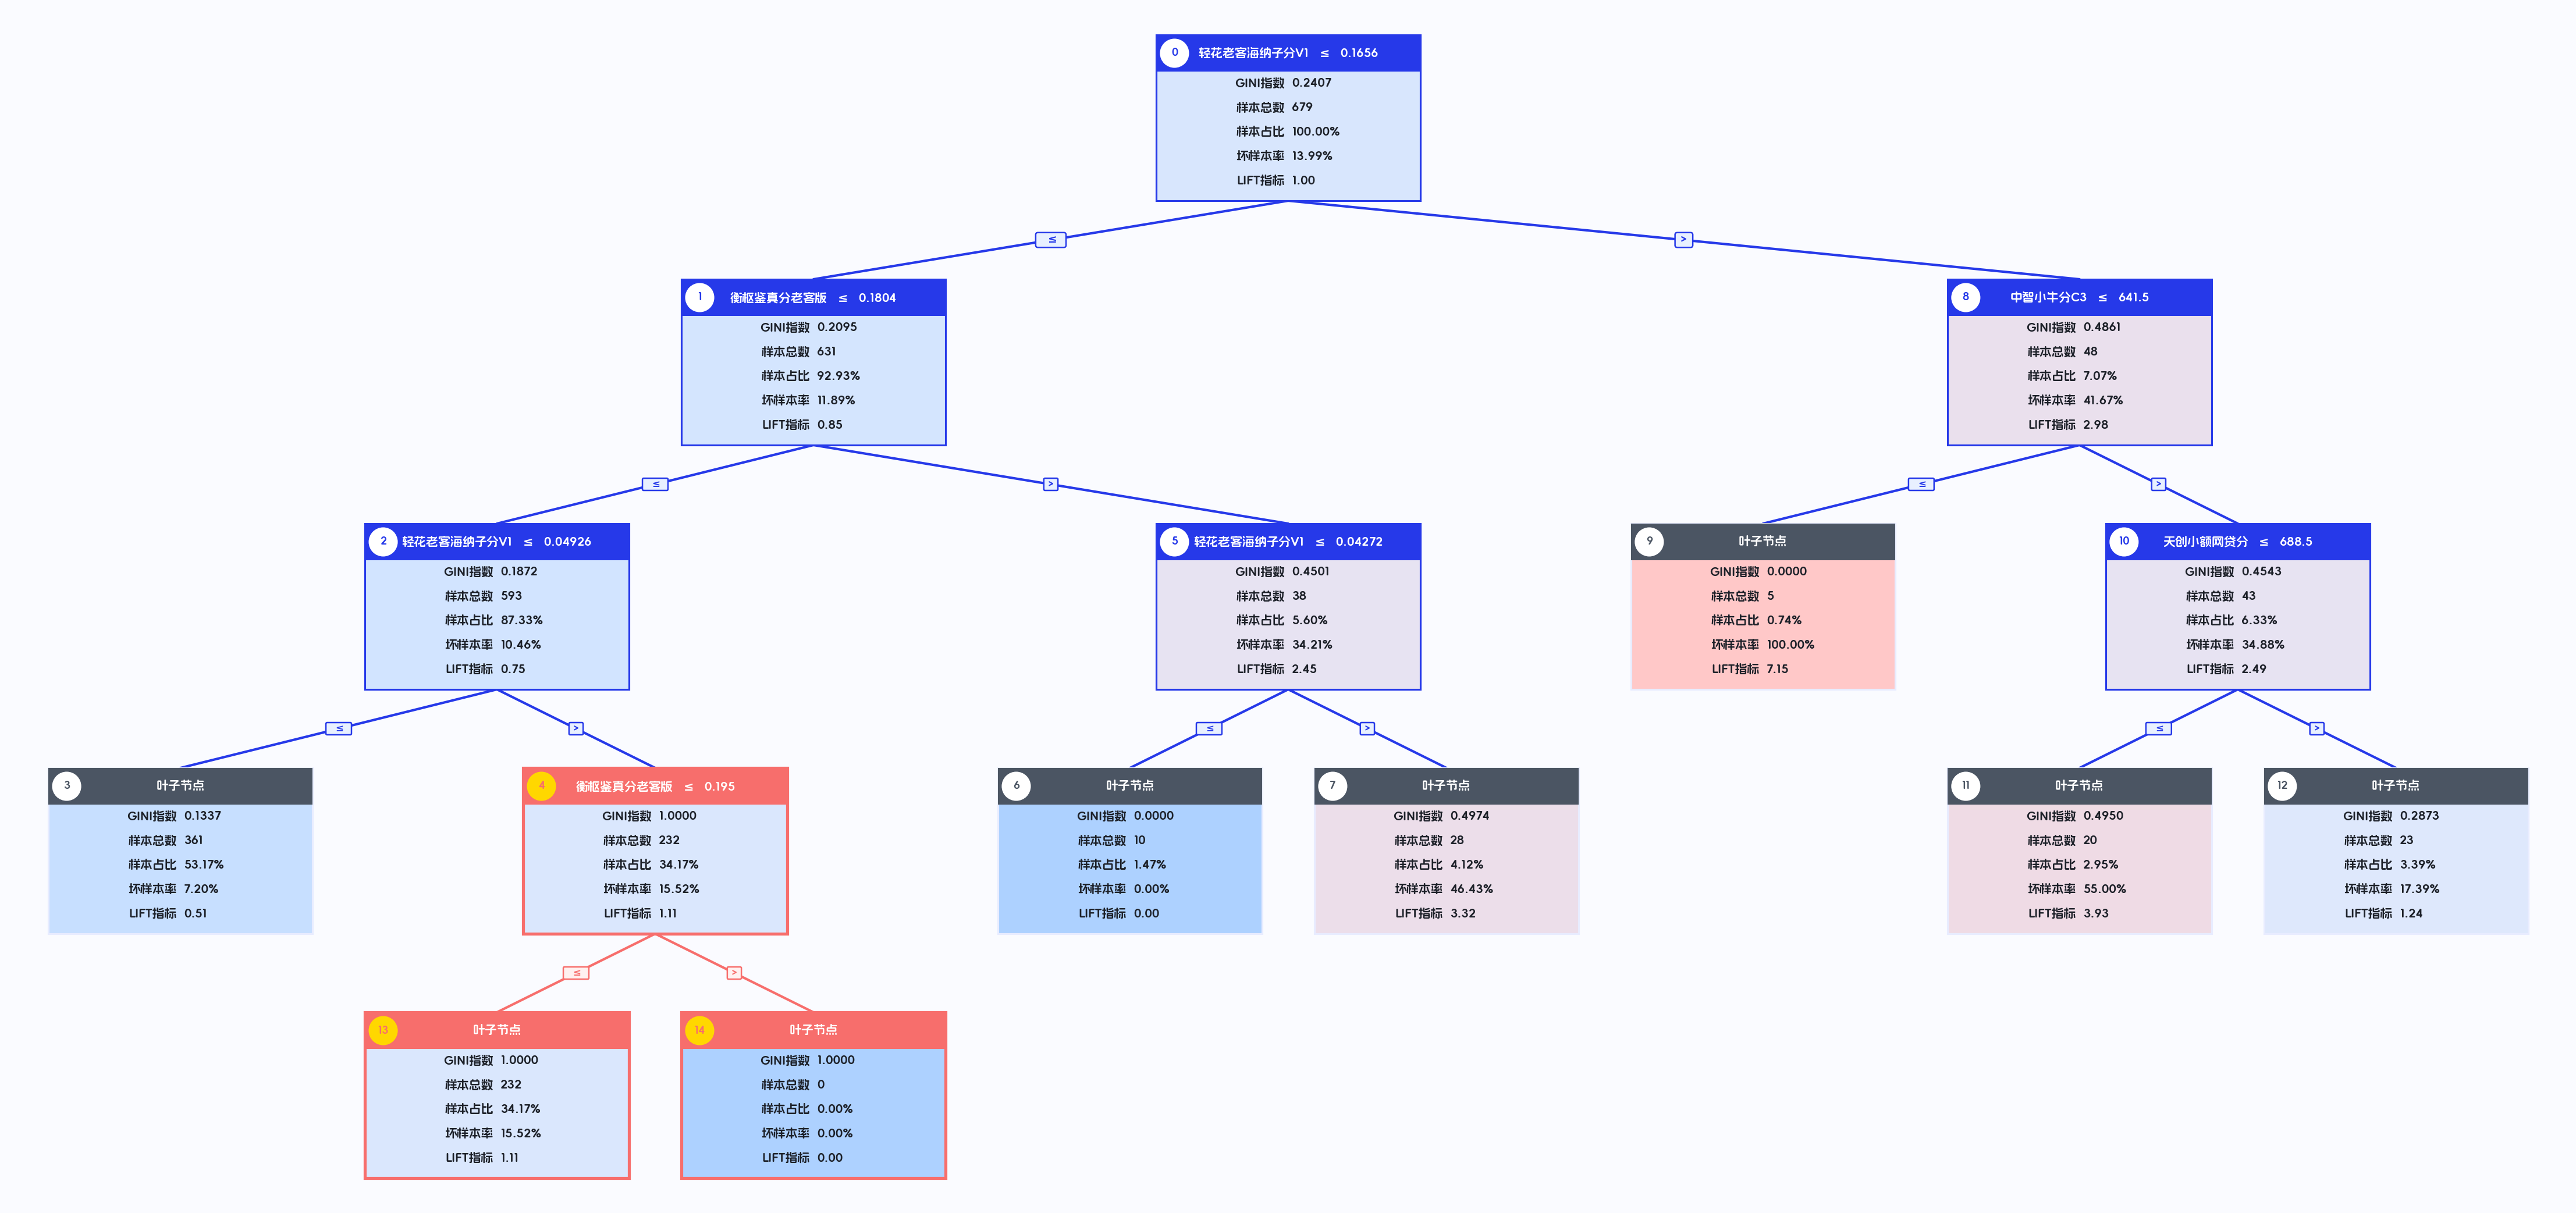

,节点编号,是否叶子,指标含义,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,1,否,轻花老客海纳子分V1 <= 0.1656(含缺失),631,92.93%,556,95.21%,75,78.95%,11.89%,0.85,-197.81%,-212.85%,15.17%,11.89%,78.95%,20.66%
1,2,否,衡枢鉴真分老客版 <= 0.1804(含缺失) 且 轻花老客海纳子分V1 <= 0.1656(含缺失),593,87.33%,531,90.92%,62,65.26%,10.46%,0.75,-174.26%,-199.53%,16.94%,10.46%,65.26%,18.02%
2,3,是,衡枢鉴真分老客版 <= 0.1804(含缺失) 且 轻花老客海纳子分V1 <= 0.0493(含缺失),361,53.17%,335,57.36%,26,27.37%,7.20%,0.51,-55.08%,-103.61%,40.50%,7.20%,27.37%,11.40%
3,4,否,衡枢鉴真分老客版 <= 0.1804(含缺失) 且 轻花老客海纳子分V1 <= 0.1656 且 轻花老客海纳子分V1 > 0.0493,232,34.17%,196,33.56%,36,37.89%,15.52%,1.11,5.66%,16.57%,62.44%,15.52%,37.89%,22.02%
4,5,否,衡枢鉴真分老客版 > 0.1804 且 轻花老客海纳子分V1 <= 0.1656(含缺失),38,5.60%,25,4.28%,13,13.68%,34.21%,2.45,8.57%,153.08%,84.24%,34.21%,13.68%,19.55%
5,6,是,衡枢鉴真分老客版 > 0.1804 且 轻花老客海纳子分V1 <= 0.0427(含缺失),10,1.47%,10,1.71%,0,0.00%,0.00%,0.00,-1.49%,-101.49%,84.54%,0.00%,0.00%,0.00%
6,7,是,衡枢鉴真分老客版 > 0.1804 且 轻花老客海纳子分V1 <= 0.1656 且 轻花老客海纳子分V1 > 0.0427,28,4.12%,15,2.57%,13,13.68%,46.43%,3.32,9.97%,241.81%,85.71%,46.43%,13.68%,21.14%
7,8,否,轻花老客海纳子分V1 > 0.1656,48,7.07%,28,4.79%,20,21.05%,41.67%,2.98,15.05%,212.85%,84.83%,41.67%,21.05%,27.97%
8,9,是,中智小牛分C3 <= 641.5000 且 轻花老客海纳子分V1 > 0.1656,5,0.74%,0,0.00%,5,5.26%,100.00%,7.15,4.56%,619.30%,86.75%,100.00%,5.26%,10.00%
9,10,否,中智小牛分C3 > 641.5000(含缺失) 且 轻花老客海纳子分V1 > 0.1656,43,6.33%,28,4.79%,15,15.79%,34.88%,2.49,10.10%,159.42%,84.09%,34.88%,15.79%,21.74%


ManualTreeExtractor(target='FPD', features=['放款金额', '中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3', '轻花老客海纳子分V1', '天创小额网贷分', '近六个月非银多头机构数', '手机号近一个月非银多头机构数', '身份证近一个月非银多头机构数', '衡枢鉴真分老客版'], samples=679, leaves=8)

In [16]:
from hscredit.report.mining import ManualTreeExtractor

# 自动最优阈值分裂（threshold=None 时用决策树自动计算最优阈值）
ext_auto = ManualTreeExtractor(target=target, max_depth=3, random_state=42)
ext_auto.fit(df_train, features=feature_list)

# display() 一行展示：决策树 graphviz 图 + 美化规则表
# ext_auto.display()

print('【自动最优阈值分裂】根节点按 衡枢鉴真分老客版 自动寻找最优阈值')
ext_auto.manual_split(
    data=df_train,
    feature='衡枢鉴真分老客版',
    threshold=0.195,
    node=4
)
# display() 一行展示：决策树 graphviz 图 + 美化规则表
ext_auto.display()

In [17]:
# 不依赖树结构，在 df_train 上用 rule.report() 验证每条规则
print('【rule.report() 验证 — 在 df_train 上独立评估每条规则】\n')
for rule in ext_auto.get_rules():
    print(f"[{rule.name}] {rule.description}")
    display(rule.report(df_train, target=target))
    print()

【rule.report() 验证 — 在 df_train 上独立评估每条规则】

[TreeNode_3] 衡枢鉴真分老客版 <= 0.1804(含缺失) 且 轻花老客海纳子分V1 <= 0.0493(含缺失)


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,((衡枢鉴真分老客版 <= 0.18043826520442963) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & ((轻花老客海纳子分V1 <= 0.04925858601927757) | (轻花老客海纳子分V1 != 轻花老客海纳子分V1)),命中,361,0.5317,335,0.5736,26,0.2737,0.0720,0.5148,-0.5508,-1.0361,0.4050,0.0720,0.2737,0.1140
1,验证规则,((衡枢鉴真分老客版 <= 0.18043826520442963) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & ((轻花老客海纳子分V1 <= 0.04925858601927757) | (轻花老客海纳子分V1 != 轻花老客海纳子分V1)),未命中,318,0.4683,249,0.4264,69,0.7263,0.2170,1.5508,0.4852,1.0361,0.5950,0.2170,0.7263,0.3341



[TreeNode_6] 衡枢鉴真分老客版 > 0.1804 且 轻花老客海纳子分V1 <= 0.0427(含缺失)


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,(衡枢鉴真分老客版 > 0.18043826520442963) & ((轻花老客海纳子分V1 <= 0.04272170551121235) | (轻花老客海纳子分V1 != 轻花老客海纳子分V1)),命中,10,0.0147,10,0.0171,0,0.0000,0.0000,0.0000,-0.0149,-1.0149,0.8454,0.0000,0.0000,0.0000
1,验证规则,(衡枢鉴真分老客版 > 0.18043826520442963) & ((轻花老客海纳子分V1 <= 0.04272170551121235) | (轻花老客海纳子分V1 != 轻花老客海纳子分V1)),未命中,669,0.9853,574,0.9829,95,1.0000,0.1420,1.0149,1.0000,1.0149,0.1546,0.1420,1.0000,0.2487



[TreeNode_7] 衡枢鉴真分老客版 > 0.1804 且 轻花老客海纳子分V1 <= 0.1656 且 轻花老客海纳子分V1 > 0.0427


...

,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,((中智小牛分C3 > 641.5) | (中智小牛分C3 != 中智小牛分C3)) & ((天创小额网贷分 > 688.5) | (天创小额网贷分 != 天创小额网贷分)) & (轻花老客海纳子分V1 > 0.16560570895671844),命中,23,0.0339,19,0.0325,4,0.0421,0.1739,1.2430,0.0085,0.2515,0.8380,0.1739,0.0421,0.0678
1,验证规则,((中智小牛分C3 > 641.5) | (中智小牛分C3 != 中智小牛分C3)) & ((天创小额网贷分 > 688.5) | (天创小额网贷分 != 天创小额网贷分)) & (轻花老客海纳子分V1 > 0.16560570895671844),未命中,656,0.9661,565,0.9675,91,0.9579,0.1387,0.9915,-0.2430,-0.2515,0.1620,0.1387,0.9579,0.2423



[TreeNode_13] 衡枢鉴真分老客版 <= 0.1804 且 轻花老客海纳子分V1 <= 0.1656 且 轻花老客海纳子分V1 > 0.0493


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,(衡枢鉴真分老客版 <= 0.18043826520442963) & (轻花老客海纳子分V1 <= 0.16560570895671844) & (轻花老客海纳子分V1 > 0.04925858601927757),命中,232,0.3417,196,0.3356,36,0.3789,0.1552,1.1091,0.0566,0.1657,0.6244,0.1552,0.3789,0.2202
1,验证规则,(衡枢鉴真分老客版 <= 0.18043826520442963) & (轻花老客海纳子分V1 <= 0.16560570895671844) & (轻花老客海纳子分V1 > 0.04925858601927757),未命中,447,0.6583,388,0.6644,59,0.6211,0.1320,0.9434,-0.1091,-0.1657,0.3756,0.1320,0.6211,0.2177



[TreeNode_14] 衡枢鉴真分老客版 <= 0.1804(含缺失) 且 衡枢鉴真分老客版 > 0.1950(含缺失) 且 轻花老客海纳子分V1 <= 0.1656 且 轻花老客海纳子分V1 > 0.0493


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,((衡枢鉴真分老客版 <= 0.18043826520442963) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & ((衡枢鉴真分老客版 > 0.195) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & (轻花老客海纳子分V1 <= 0.16560570895671844) & (轻花老客海纳子分V1 > 0.04925858601927757),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8601,0.0000,0.0000,0.0000
1,验证规则,((衡枢鉴真分老客版 <= 0.18043826520442963) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & ((衡枢鉴真分老客版 > 0.195) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & (轻花老客海纳子分V1 <= 0.16560570895671844) & (轻花老客海纳子分V1 > 0.04925858601927757),未命中,679,1.0000,584,1.0000,95,1.0000,0.1399,1.0000,1.0000,1.0000,0.1399,0.1399,1.0000,0.2455


## B4. 链式调用：多层分裂 + 规则验证

`manual_split` 支持**链式调用**，可对不同节点依次进行分裂，并在 df_train 上通过 `rule.report()` 验证每条规则的有效性。

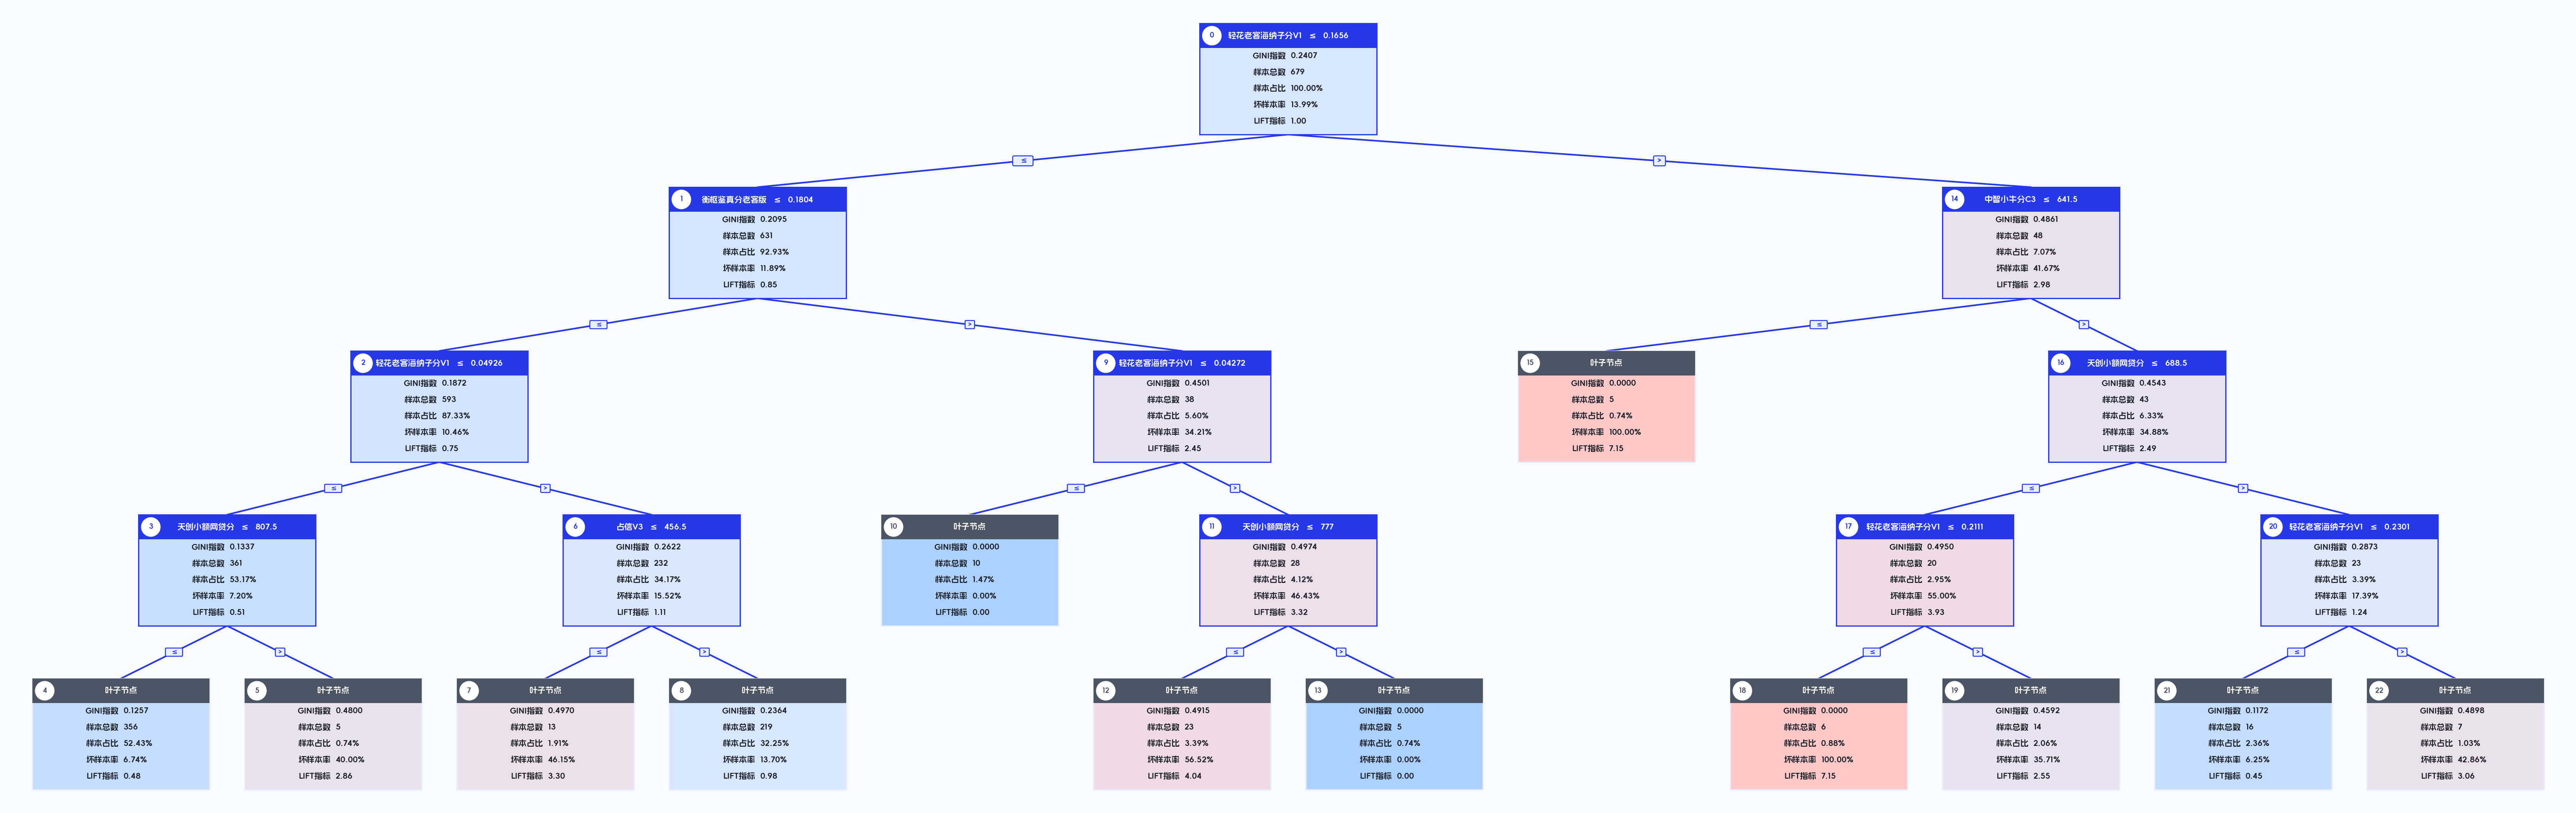

,节点编号,是否叶子,指标含义,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,1,否,轻花老客海纳子分V1 <= 0.1656(含缺失),631,92.93%,556,95.21%,75,78.95%,11.89%,0.85,-197.81%,-212.85%,15.17%,11.89%,78.95%,20.66%
1,2,否,衡枢鉴真分老客版 <= 0.1804(含缺失) 且 轻花老客海纳子分V1 <= 0.1656(含缺失),593,87.33%,531,90.92%,62,65.26%,10.46%,0.75,-174.26%,-199.53%,16.94%,10.46%,65.26%,18.02%
2,3,否,衡枢鉴真分老客版 <= 0.1804(含缺失) 且 轻花老客海纳子分V1 <= 0.0493(含缺失),361,53.17%,335,57.36%,26,27.37%,7.20%,0.51,-55.08%,-103.61%,40.50%,7.20%,27.37%,11.40%
3,4,是,天创小额网贷分 <= 807.5000(含缺失) 且 衡枢鉴真分老客版 <= 0.1804(含缺失) 且 轻花老客海纳子分V1 <= 0.0493(含缺失),356,52.43%,332,56.85%,24,25.26%,6.74%,0.48,-57.11%,-108.92%,40.65%,6.74%,25.26%,10.64%
4,5,是,天创小额网贷分 > 807.5000 且 衡枢鉴真分老客版 <= 0.1804(含缺失) 且 轻花老客海纳子分V1 <= 0.0493(含缺失),5,0.74%,3,0.51%,2,2.11%,40.00%,2.86,1.38%,187.27%,85.86%,40.00%,2.11%,4.00%
5,6,否,衡枢鉴真分老客版 <= 0.1804(含缺失) 且 轻花老客海纳子分V1 <= 0.1656 且 轻花老客海纳子分V1 > 0.0493,232,34.17%,196,33.56%,36,37.89%,15.52%,1.11,5.66%,16.57%,62.44%,15.52%,37.89%,22.02%
6,7,是,占信V3 <= 456.5000 且 衡枢鉴真分老客版 <= 0.1804(含缺失) 且 轻花老客海纳子分V1 <= 0.1656 且 轻花老客海纳子分V1 > 0.0493,13,1.91%,7,1.20%,6,6.32%,46.15%,3.30,4.49%,234.37%,85.86%,46.15%,6.32%,11.11%
7,8,是,占信V3 > 456.5000(含缺失) 且 衡枢鉴真分老客版 <= 0.1804(含缺失) 且 轻花老客海纳子分V1 <= 0.1656 且 轻花老客海纳子分V1 > 0.0493,219,32.25%,189,32.36%,30,31.58%,13.70%,0.98,-1.00%,-3.09%,62.59%,13.70%,31.58%,19.11%
8,9,否,衡枢鉴真分老客版 > 0.1804 且 轻花老客海纳子分V1 <= 0.1656(含缺失),38,5.60%,25,4.28%,13,13.68%,34.21%,2.45,8.57%,153.08%,84.24%,34.21%,13.68%,19.55%
9,10,是,衡枢鉴真分老客版 > 0.1804 且 轻花老客海纳子分V1 <= 0.0427(含缺失),10,1.47%,10,1.71%,0,0.00%,0.00%,0.00,-1.49%,-101.49%,84.54%,0.00%,0.00%,0.00%


【链式分裂 — 第1步】


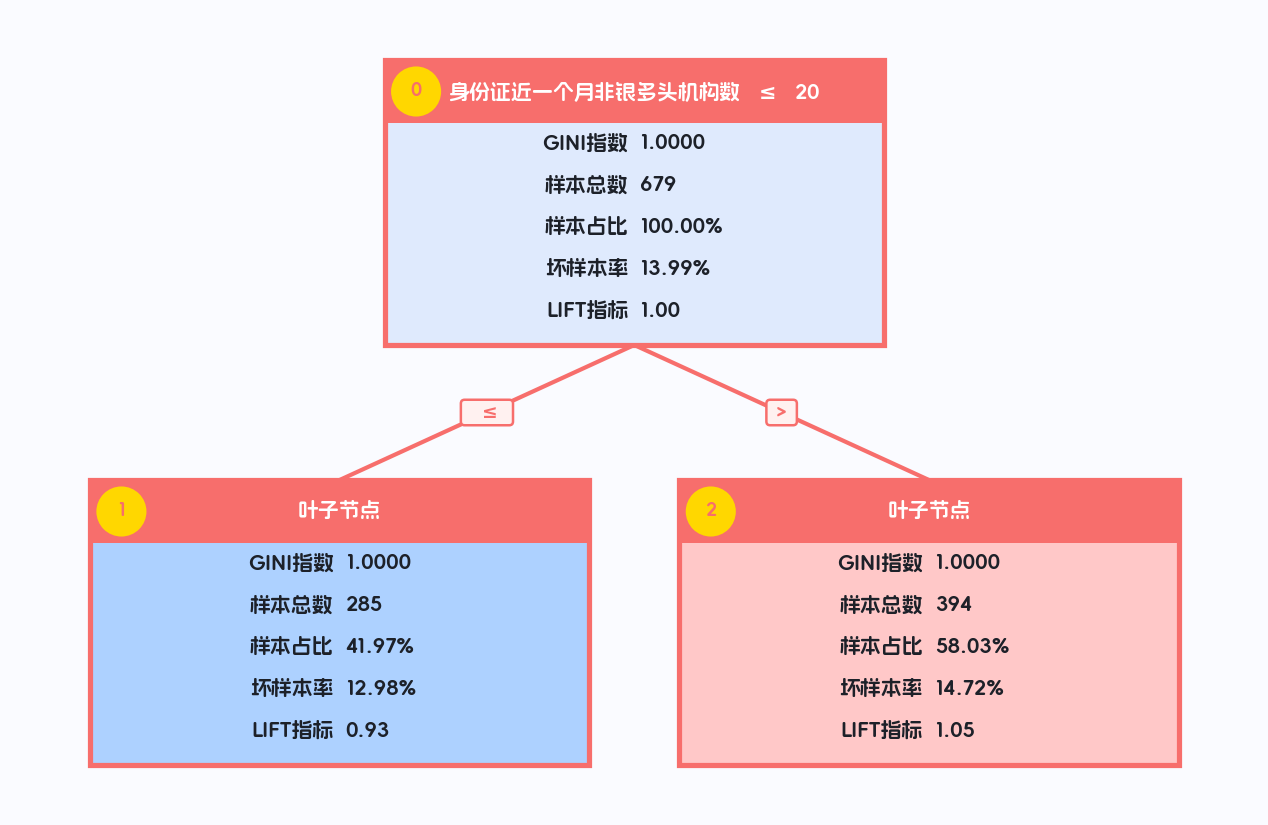

,节点编号,是否叶子,指标含义,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,1,是,身份证近一个月非银多头机构数 <= 20.0000,285,41.97%,248,42.47%,37,38.95%,12.98%,0.93,-5.22%,-12.42%,54.93%,12.98%,38.95%,19.47%
1,2,是,身份证近一个月非银多头机构数 > 20.0000(含缺失),394,58.03%,336,57.53%,58,61.05%,14.72%,1.05,7.21%,12.42%,45.07%,14.72%,61.05%,23.72%


【链式分裂 — 第2步】


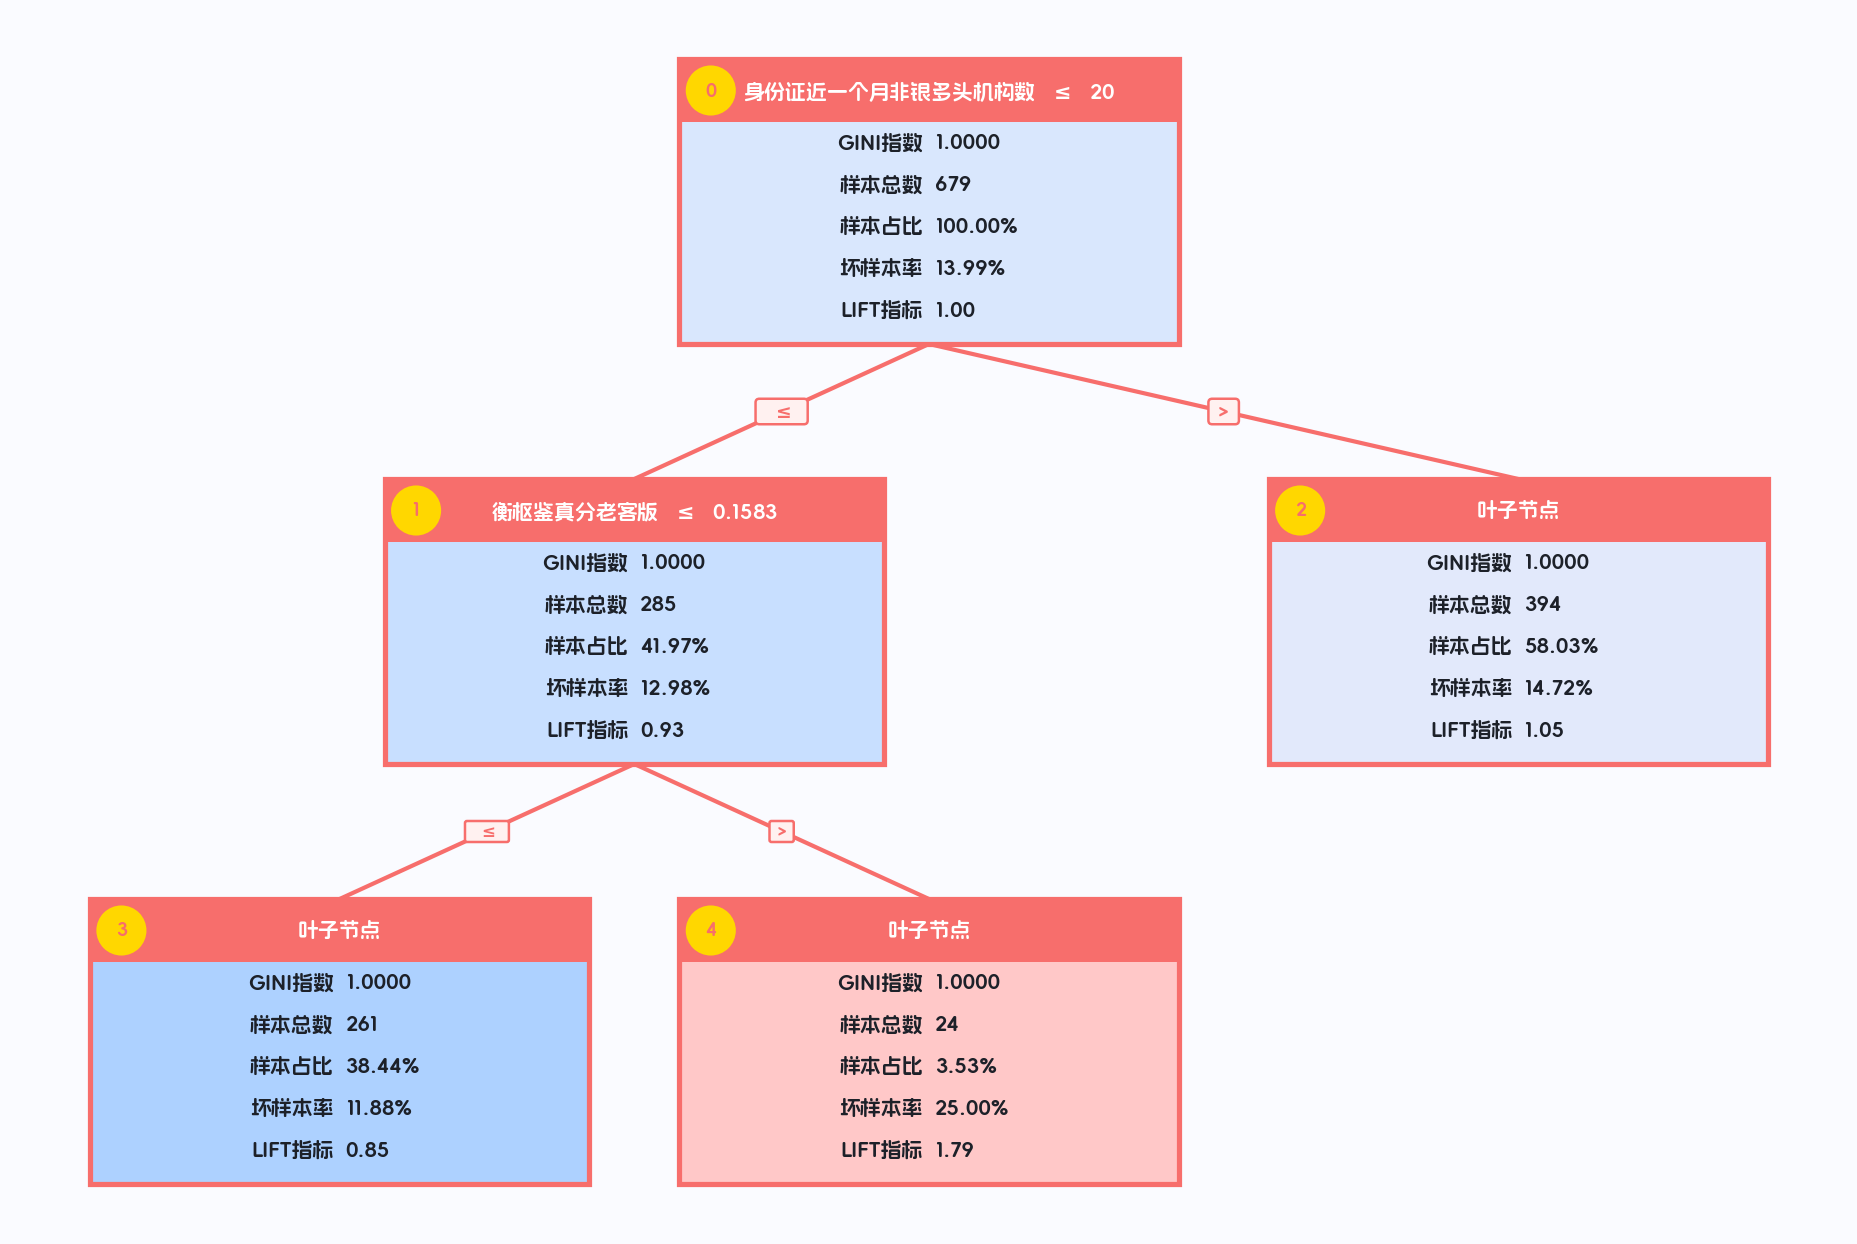

,节点编号,是否叶子,指标含义,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,1,否,身份证近一个月非银多头机构数 <= 20.0000,285,41.97%,248,42.47%,37,38.95%,12.98%,0.93,-5.22%,-12.42%,54.93%,12.98%,38.95%,19.47%
1,2,是,身份证近一个月非银多头机构数 > 20.0000(含缺失),394,58.03%,336,57.53%,58,61.05%,14.72%,1.05,7.21%,12.42%,45.07%,14.72%,61.05%,23.72%
2,3,是,衡枢鉴真分老客版 <= 0.1583 且 身份证近一个月非银多头机构数 <= 20.0000,261,38.44%,230,39.38%,31,32.63%,11.88%,0.85,-9.43%,-24.54%,56.70%,11.88%,32.63%,17.42%
3,4,是,衡枢鉴真分老客版 > 0.1583(含缺失) 且 身份证近一个月非银多头机构数 <= 20.0000,24,3.53%,18,3.08%,6,6.32%,25.00%,1.79,2.88%,81.57%,84.24%,25.00%,6.32%,10.08%


ManualTreeExtractor(target='FPD', features=['放款金额', '中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3', '轻花老客海纳子分V1', '天创小额网贷分', '近六个月非银多头机构数', '手机号近一个月非银多头机构数', '身份证近一个月非银多头机构数', '衡枢鉴真分老客版'], samples=679, leaves=3)

In [18]:
# 链式分裂：多层逐步注入业务经验
ext_chain = ManualTreeExtractor(target=target, max_depth=4, random_state=42)
ext_chain.fit(df_train, features=feature_list)
# display() 一行展示：决策树 graphviz 图 + 美化规则表
ext_chain.display()

# 第1步：根节点按身份证近一个月非银多头机构数 > 15 分裂
print('【链式分裂 — 第1步】')
ext_chain.manual_split(
    data=df_train[df_train['身份证近一个月非银多头机构数'] > 15],
    feature='身份证近一个月非银多头机构数',
    threshold=20,
    node=0
)
# display() 一行展示：决策树 graphviz 图 + 美化规则表
ext_chain.display()

# 第2步：在节点1（右侧子节点）继续按衡枢鉴真分分裂
print('【链式分裂 — 第2步】')
ext_chain.manual_split(
    data=df_train[df_train['身份证近一个月非银多头机构数'] > 20],
    feature='衡枢鉴真分老客版',
    threshold=None,
    node=1
)
# display() 一行展示：决策树 graphviz 图 + 美化规则表
ext_chain.display()

In [19]:
# 不依赖树结构，在 df_train 上用 rule.report() 验证每条规则
print('【rule.report() 验证 — 在 df_train 上独立评估每条规则】\n')
for rule in ext_chain.get_rules():
    print(f"[{rule.name}] {rule.description}")
    display(rule.report(df_train, target=target))
    print()

【rule.report() 验证 — 在 df_train 上独立评估每条规则】

[TreeNode_2] 身份证近一个月非银多头机构数 > 20.0000(含缺失)


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,((身份证近一个月非银多头机构数 > 20.0) | (身份证近一个月非银多头机构数 != 身份证近一个月非银多头机构数)),命中,394,0.5803,336,0.5753,58,0.6105,0.1472,1.0522,0.0721,0.1242,0.4507,0.1472,0.6105,0.2372
1,验证规则,((身份证近一个月非银多头机构数 > 20.0) | (身份证近一个月非银多头机构数 != 身份证近一个月非银多头机构数)),未命中,285,0.4197,248,0.4247,37,0.3895,0.1298,0.9279,-0.0522,-0.1242,0.5493,0.1298,0.3895,0.1947



[TreeNode_3] 衡枢鉴真分老客版 <= 0.1583 且 身份证近一个月非银多头机构数 <= 20.0000


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,(衡枢鉴真分老客版 <= 0.15831636637449265) & (身份证近一个月非银多头机构数 <= 20.0),命中,261,0.3844,230,0.3938,31,0.3263,0.1188,0.8489,-0.0943,-0.2454,0.5670,0.1188,0.3263,0.1742
1,验证规则,(衡枢鉴真分老客版 <= 0.15831636637449265) & (身份证近一个月非银多头机构数 <= 20.0),未命中,418,0.6156,354,0.6062,64,0.6737,0.1531,1.0943,0.1511,0.2454,0.4330,0.1531,0.6737,0.2495



[TreeNode_4] 衡枢鉴真分老客版 > 0.1583(含缺失) 且 身份证近一个月非银多头机构数 <= 20.0000


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,((衡枢鉴真分老客版 > 0.15831636637449265) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & (身份证近一个月非银多头机构数 <= 20.0),命中,24,0.0353,18,0.0308,6,0.0632,0.2500,1.7868,0.0288,0.8157,0.8424,0.2500,0.0632,0.1008
1,验证规则,((衡枢鉴真分老客版 > 0.15831636637449265) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & (身份证近一个月非银多头机构数 <= 20.0),未命中,655,0.9647,566,0.9692,89,0.9368,0.1359,0.9712,-0.7868,-0.8157,0.1576,0.1359,0.9368,0.2373


## B5. 测试集评估 + 规则验证\n\n在测试集上评估链式分裂的规则效果，并在 df_test 上通过 `rule.report()` 独立验证。

In [20]:
# 在测试集上评估链式分裂规则效果
eval_result = ext_chain.report(df_test)
print(f'测试集样本: {len(df_test):,}, 总体坏账率: {df_test[target].mean():.2%}')
leaf_eval = eval_result[eval_result['是否叶子'] == '是']
style_rule_table(leaf_eval, overall_badrate=df_test[target].mean())

测试集样本: 291, 总体坏账率: 14.09%


,节点编号,是否叶子,指标含义,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
1,2,是,身份证近一个月非银多头机构数 > 20.0000(含缺失),184,63.23%,160,64.00%,24,58.54%,13.04%,0.93,-12.76%,-20.19%,39.18%,13.04%,58.54%,21.33%
2,3,是,衡枢鉴真分老客版 <= 0.1583 且 身份证近一个月非银多头机构数 <= 20.0000,99,34.02%,85,34.00%,14,34.15%,14.14%,1.00,0.19%,0.56%,61.51%,14.14%,34.15%,20.00%
3,4,是,衡枢鉴真分老客版 > 0.1583(含缺失) 且 身份证近一个月非银多头机构数 <= 20.0000,8,2.75%,5,2.00%,3,7.32%,37.50%,2.66,4.70%,170.86%,85.22%,37.50%,7.32%,12.24%


In [21]:
# rule.report() 在测试集上独立验证
print('【rule.report() 验证 — 在 df_test 上独立评估每条规则】\n')
for rule in ext_chain.get_rules():
    print(f"[{rule.name}] {rule.description}")
    display(rule.report(df_test, target=target))
    print()

【rule.report() 验证 — 在 df_test 上独立评估每条规则】

[TreeNode_2] 身份证近一个月非银多头机构数 > 20.0000(含缺失)


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,((身份证近一个月非银多头机构数 > 20.0) | (身份证近一个月非银多头机构数 != 身份证近一个月非银多头机构数)),命中,184,0.6323,160,0.6400,24,0.5854,0.1304,0.9258,-0.1276,-0.2019,0.3918,0.1304,0.5854,0.2133
1,验证规则,((身份证近一个月非银多头机构数 > 20.0) | (身份证近一个月非银多头机构数 != 身份证近一个月非银多头机构数)),未命中,107,0.3677,90,0.3600,17,0.4146,0.1589,1.1276,0.0742,0.2019,0.6082,0.1589,0.4146,0.2297



[TreeNode_3] 衡枢鉴真分老客版 <= 0.1583 且 身份证近一个月非银多头机构数 <= 20.0000


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,(衡枢鉴真分老客版 <= 0.15831636637449265) & (身份证近一个月非银多头机构数 <= 20.0),命中,99,0.3402,85,0.3400,14,0.3415,0.1414,1.0037,0.0019,0.0056,0.6151,0.1414,0.3415,0.2000
1,验证规则,(衡枢鉴真分老客版 <= 0.15831636637449265) & (身份证近一个月非银多头机构数 <= 20.0),未命中,192,0.6598,165,0.6600,27,0.6585,0.1406,0.9981,-0.0037,-0.0056,0.3849,0.1406,0.6585,0.2318



[TreeNode_4] 衡枢鉴真分老客版 > 0.1583(含缺失) 且 身份证近一个月非银多头机构数 <= 20.0000


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,((衡枢鉴真分老客版 > 0.15831636637449265) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & (身份证近一个月非银多头机构数 <= 20.0),命中,8,0.0275,5,0.0200,3,0.0732,0.3750,2.6616,0.0470,1.7086,0.8522,0.3750,0.0732,0.1224
1,验证规则,((衡枢鉴真分老客版 > 0.15831636637449265) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & (身份证近一个月非银多头机构数 <= 20.0),未命中,283,0.9725,245,0.9800,38,0.9268,0.1343,0.9530,-1.6616,-1.7086,0.1478,0.1343,0.9268,0.2346


## B6. 规则效果对比

=== 数据驱动树（DecisionTreeAnalyzer）=== Leaf Nodes ===
叶子节点数: 4
最高LIFT: 2.5348
坏样本率范围: 0.00% ~ 35.71%

=== 人工调整树（ManualTreeExtractor）=== Leaf Nodes ===
叶子节点数: 3
最高LIFT: 2.6616
坏样本率范围: 13.04% ~ 37.50%


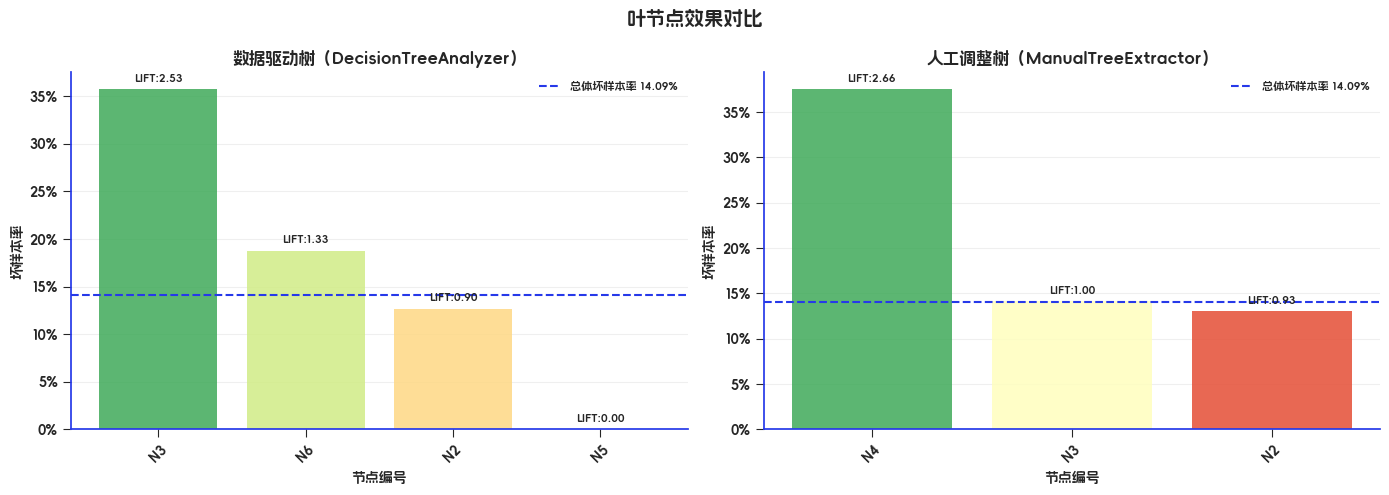

In [22]:
# 数据驱动树 vs 人工调整树 — 叶子节点效果对比
from hscredit.core.viz import tree_leaf_comparison_plot

auto_eval = fitter.report(df_test)
auto_leaf = auto_eval[auto_eval['是否叶子'] == '是'].copy()
manual_leaf = leaf_eval.copy()

print('=== 数据驱动树（DecisionTreeAnalyzer）=== Leaf Nodes ===')
print(f'叶子节点数: {len(auto_leaf)}')
print(f'最高LIFT: {auto_leaf["LIFT值"].max():.4f}')
print(f'坏样本率范围: {auto_leaf["坏样本率"].min():.2%} ~ {auto_leaf["坏样本率"].max():.2%}')

print('\n=== 人工调整树（ManualTreeExtractor）=== Leaf Nodes ===')
print(f'叶子节点数: {len(manual_leaf)}')
print(f'最高LIFT: {manual_leaf["LIFT值"].max():.4f}')
print(f'坏样本率范围: {manual_leaf["坏样本率"].min():.2%} ~ {manual_leaf["坏样本率"].max():.2%}')

fig = tree_leaf_comparison_plot(
    {
        '数据驱动树（DecisionTreeAnalyzer）': auto_leaf,
        '人工调整树（ManualTreeExtractor）': manual_leaf,
    },
    overall_bad_rate=df_test[target].mean(),
    figsize=(14, 5),
)

## 小结

| 工具 | 主要方法 | 说明 |
|------|----------|------|
| **DecisionTreeAnalyzer** | `fit()` | 训练标准 sklearn 决策树 |
|  | `evaluate(metric_type)` | AUC/KS/LIFT 评估 |
|  | `get_rule_table()` | 节点统计表 |
|  | `report()` | 按节点评估数据 |
|  | `get_rules()` | 叶子规则转 Rule 对象 |
|  | `save() / load()` | 模型持久化 |
| **ManualTreeExtractor** | `fit()` | 训练基础决策树 |
|  | `manual_split()` | 人工/自动分裂，支持链式调用 |
|  | `delete_node()` | 删除子树变叶子 |
|  | `get_rule_table()` | 节点统计表 |
|  | `report()` | 在新数据上评估 |
|  | `get_rules()` | 叶子规则转 Rule 对象 |
|  | `display()` | 在 Jupyter 中展示决策树图 + 美化规则表 |